In [1]:
import os #operating system

%matplotlib inline 
from matplotlib import pyplot as plt #biblioteca de plotagem do matplotlib
import numpy as np
from photutils.aperture import EllipticalAperture #pra fotometria astronomica 

In [2]:
# Use custom style for larger fonts and figures
plt.style.use('guide.mplstyle')

In [3]:
# Set up the random number generator, allowing a seed to be set from the environment
seed = os.getenv('GUIDE_RANDOM_SEED', None)

if seed is not None:
    seed = int(seed)
    
# This is the generator to use for any image component which changes in each image, e.g. read noise
# or Poisson error
noise_rng = np.random.default_rng(seed)

In [4]:
from convenience_functions import show_image

<h1 style="text-align: center; font-family: 'menlo'; color: #ADD8E6; font-size:40px;">
  <span style="background-color: #191970; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Blank Image
  </span>
</h1>

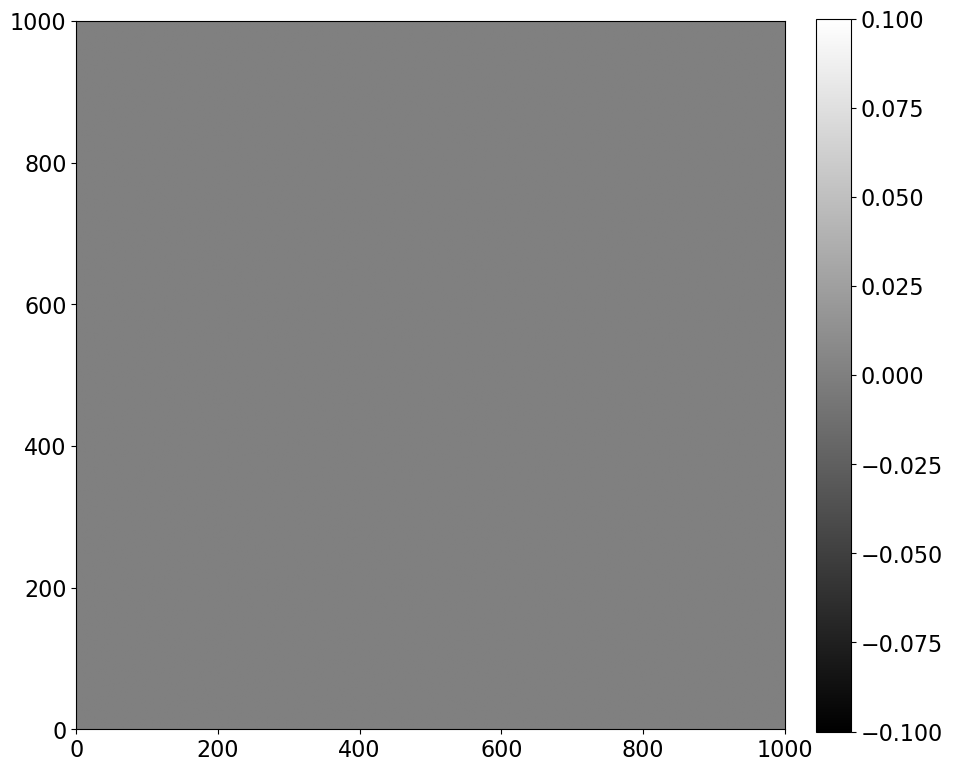

In [5]:
synthetic_image = np.zeros([1000, 1000])
show_image(synthetic_image, cmap='gray')

<h1 style="text-align: center; font-family: 'menlo'; color: #ADD8E6; font-size:40px;">
  <span style="background-color: #191970; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Read Noise
  </span>
</h1>

'Ruído de leitura'<br>Random electronic noise from readout that varies per exposure and pixel. Read Noise is the tiny, random variation added by your camera’s electronics each time an exposure is read out by the sensor and converted into digital data. Note that each time you run this function you’ll get a different set of pixels so that it behaves like real noise.

<Figure size 1000x1000 with 0 Axes>

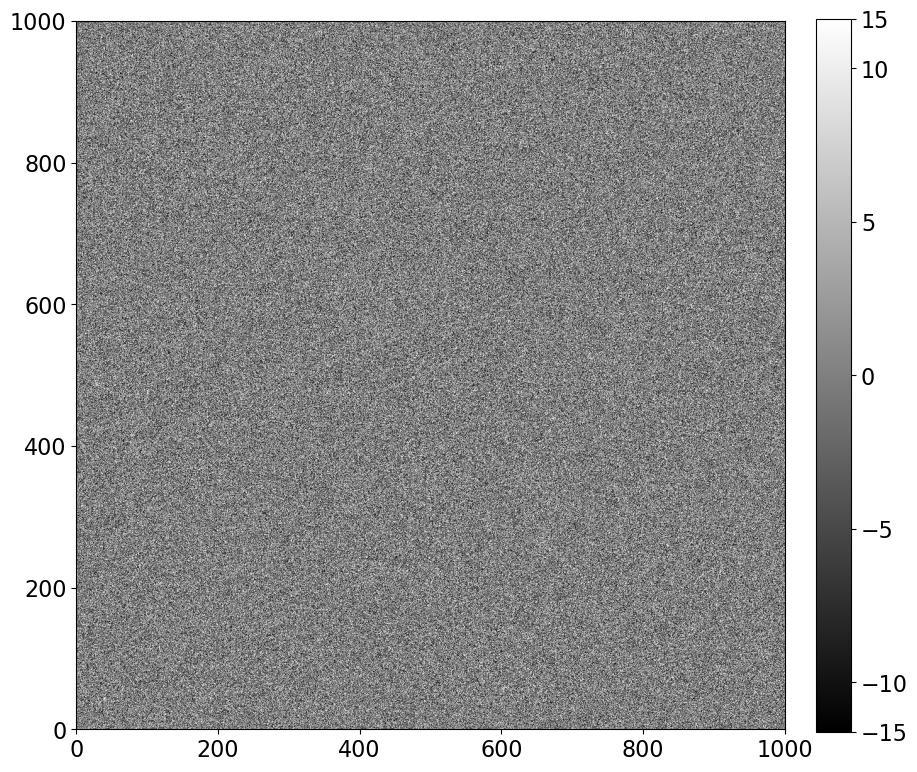

In [6]:
def read_noise(image, amount, gain=1):
                shape = image.shape
                noise = noise_rng.normal(scale=amount/gain, size=shape) 
                return noise
#image e amount são parametros de entrada, amount é a quntidade de ruído em elétrons

#noise_rng é o aleatório que colocamos lá em cima
#.normal() é a função que gera números com a distribuição normal (Gaussiana)
#scale=amount/gain é a coisa toda que ta explicada no comentário aí em cima
    #exemplo: se amount=5 e gain=1 → scale=5/1  = 5 ADU, quanto menor esse número, menor o ruído
#size=shape é que vai ficar do mesmo tamanho que a imagem de entrada

'''
gain=1 é um parametro opcional, ganho de camera

Gain é uma 'ponte' entre elétrons e ADU → GAIN = (elétrons) / (ADU) 
Quantos elétrons são necessários para aumentar 1 unidade no ADU?
exemplos:
Gain = 1 e⁻/ADU	1 elétron vira 1 ADU
Gain = 2 e⁻/ADU	Precisam 2 elétrons para 1 ADU (menos sensível)
Gain = 0.5 e⁻/ADU	1 elétron vira 2 ADU (mais sensível)
'''

plt.figure()
noise_im=synthetic_image + read_noise(synthetic_image, 5) #amount = 5, ruído de 5 elétrons
show_image(noise_im, cmap='gray')

<h1 style="text-align: center; font-family: 'menlo'; color: #ADD8E6; font-size:40px;">
  <span style="background-color: #191970; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Bias
  </span>
</h1>

*Site:*

Bias is an offset voltage (which translates into some non-zero number of counts) added to every pixel in the image to ensure that when voltages are converted to counts there is never a negative count. Note that in the noise image above, some counts are positive and some are negative, as you would expect for a Gaussian distribution centered on zero. Pixel values are typically read out from the electronics as positive numbers, though. Adding a constant voltage, which corresponds to a constant, positive number, ensures that even an image which consists entirely of noise has no negative values.

To model a bias image, we create a uniform array and, optionally, add in some “bad” columns. The bad columns are exaggerated here to ensure they are visible.

The bad columns in a CCD are typically stable over a very long time. A random number generator is used below to pick which columns in our CCD are bad, but we’ll use a seed to make sure that each time we generate the bias we get the same bad columns (and pixel values within the bad columns).

This stability is what makes it possible to correct for the effect in real images.

Finally, note that the bias doesn’t depend on exposure time. That’s because a bias exposure is a zero-second exposure in which the camera simply reads the chip out.

-----

*Site links:*

Your Camera inherently has a base level of read-out noise as it reads the values of each pixel of the sensor, called bias. When averaged out, basically it’s an inherent gradient to the sensor. BIAS frames are meant to capture this so it can be removed.

Bias frames are used to calibrate out the sensor camera’s readout noise.  As electricity flows through your camera to take the image, there is signal noise from the electricity used to do this.  The requirements to take bias frames are the same as taking dark frames except that the exposure time is usually 0.1 seconds or less.  Again, 30 to 50 of these kinds of sub exposures should be taken, stacked and integrated into a master bias file.

Text(0.5, 1.0, 'Bias alone, bad columns included')

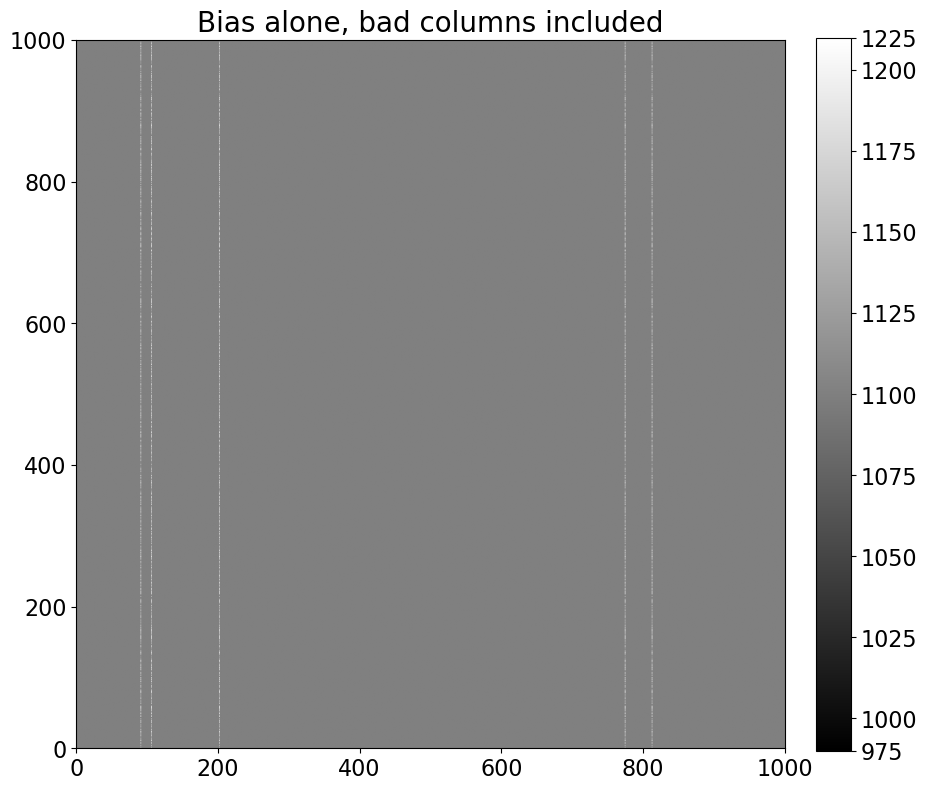

In [11]:
#realistic=False , opcional / false=padrão / true=columns with somewhat higher bias value
def bias(image, value, realistic=False):
    bias_im = np.zeros_like(image) + value
    
#if we want a more realistic bias we need to do a little more work. 
    if realistic:
        shape = image.shape  
        number_of_columns = 5  #5 colunas defeituosas
        rng = np.random.RandomState(seed=8392) #gerador de números 'aleatórios' (o bias é estável, n muda de imagem p imagem), as colunas defeituosas estarão sempre nos mesmos lugares
        columns = rng.randint(0, shape[1], size=number_of_columns) #rng.randint(0, shape[1]) = escolhe números inteiros aleatórios entre 0 e (largura da imagem) 1 / vai gerar 5 nmrs pk 'size=number_of_columns'
        col_pattern = rng.randint(0, int(0.1 * value), size=shape[0]) #padrão de variação das colunas / int(0.1*value)=10% do valor do bias, definido em 'bias_only' (1100 (valor do bias em ADU) → 110) / size=shape[0]=um valor diferente para cada linha da imagem
        
        for c in columns: #pra cada linha defeituosa
            bias_im[:, c] = value + col_pattern
    
    return bias_im

bias_only = bias(synthetic_image, 1100, realistic=True) #bias de 1100 ADU
show_image(bias_only, cmap='gray', figsize=(10,10)) #figsize é tamanho maior, 10x10 polegadas
plt.title('Bias alone, bad columns included', fontsize='20')

Text(0.5, 1.0, 'Realistic bias frame with red noise')

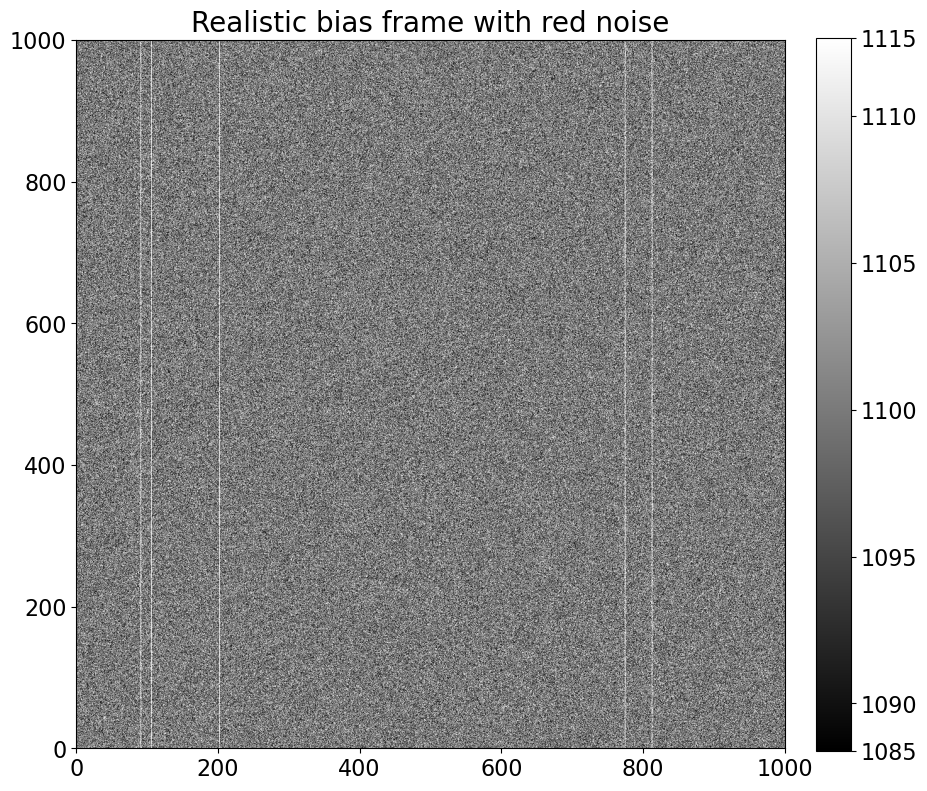

In [12]:
#add noise
bias_noise_im = noise_im + bias_only
show_image(bias_noise_im, cmap='gray', figsize=(10,10))
plt.title('Realistic bias frame with red noise', fontsize=20)

<h1 style="text-align: center; font-family: 'menlo'; color: #ADD8E6; font-size:40px;">
  <span style="background-color: #191970; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Sky Background
  </span>
</h1>

<h1 style="text-align: center; font-family: 'menlo'; color: #ADD8E6; font-size:40px;">
  <span style="background-color: #191970; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Add Stars
  </span>
</h1>

<h1 style="text-align: center; font-family: 'menlo'; color: #ADD8E6; font-size:40px;">
  <span style="background-color: #191970; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Summary
  </span>
</h1>

<h1 style="text-align: left; font-family: 'menlo'; color: #191970; font-size:40px;">
  <span style="background-color: #ADD8E6; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Notes
  </span>
</h1>

**Charge-Coupled Device (CCD)**: sensor that operates like a grid of "buckets" (pixels) that collect electrons released by light.

**ADU**: Analog-to-digital unit, número que o computador armazena para cada pixel da imagem. Quando abre uma imagem FITS, cada pixel tem um valor em ADU.

Fóton atinge o CCD → Fótons viram elétrons (fotoelétrons, cada fóton pode liberar um elétron no sensor) → Elétrons viram voltagem (convertidos em tensão elétrica ao ler o CCD) → Voltagem vira um número ADU (o conversor A/D transforma a voltagem em número inteiro).

**FITS**: Flexible Image Transport System, padrão de imagens e dados astronomicos

**Read noise**: Ruído de leitura<br>**Bias**: Nível de referencia 

<h1 style="text-align: left; font-family: 'menlo'; color: #191970; font-size:40px;">
  <span style="background-color: #ADD8E6; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Links
  </span>
</h1>

https://github.com/astropy/ccd-reduction-and-photometry-guide<br>https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/01-03-Construction-of-an-artificial-but-realistic-image.html<br>https://mypetstars.com/glossary/read-noise<br>https://practicalastrophotography.com/a-brief-guide-to-calibration-frames/<br>https://telescope.live/blog/understanding-calibration-frames#:~:text=Bias%20Frames&text=As%20electricity%20flows%20through%20your,the%20comfort%20of%20your%20home.

https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html<br>https://brains.dev/2022/jupyter-notebooks-dicas-de-formatacao/